# NASA IMS Bearing Dataset — Time Domain Feature Engineering
We formalize the health indicators computed in the previous notebook and add 
two additional features: Crest Factor and Peak-to-Peak amplitude.
Together these 5 features form a classical vibration health monitoring fingerprint.

| Feature | What it measures |
|---|---|
| RMS | Overall energy / vibration intensity |
| Kurtosis | Impulsive shocks — early fault indicator |
| Crest Factor | Ratio of peak to RMS — sensitive to early defects |
| Peak-to-Peak | Maximum swing of the signal |
| Std Dev | Spread of the signal around the mean |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR = Path("../data/1st_test")
BEARINGS = ["bearing_1", "bearing_2", "bearing_3", "bearing_4"]
COLORS = ["steelblue", "crimson", "seagreen", "darkorange"]

## Feature Extraction
We process each file once and extract all 5 features per bearing per timestamp.
This produces a clean feature matrix, the foundation of any predictive maintenance model.

In [2]:
def extract_features(data_dir):
    files = sorted(data_dir.iterdir())
    records = []

    for file in files:
        if not file.is_file():
            continue

        df = pd.read_csv(
            file, sep="\t", header=None,
            names=BEARINGS
        )

        parts = file.name.split(".")
        timestamp = pd.Timestamp(
            year=int(parts[0]), month=int(parts[1]), day=int(parts[2]),
            hour=int(parts[3]), minute=int(parts[4]), second=int(parts[5])
        )

        record = {"timestamp": timestamp}
        for b in BEARINGS:
            signal = df[b].values
            rms = np.sqrt(np.mean(signal**2))

            record[f"{b}_rms"]        = rms
            record[f"{b}_std"]        = np.std(signal)
            record[f"{b}_kurtosis"]   = pd.Series(signal).kurtosis()
            record[f"{b}_peak"]       = np.max(np.abs(signal))
            record[f"{b}_crest"]      = np.max(np.abs(signal)) / (rms + 1e-10)
            record[f"{b}_peak2peak"]  = np.max(signal) - np.min(signal)

        records.append(record)

    return pd.DataFrame(records).set_index("timestamp")

features = extract_features(DATA_DIR)
print(f"Feature matrix shape: {features.shape}")
features.head()

Feature matrix shape: (2156, 24)


,bearing_1_rms,bearing_1_std,bearing_1_kurtosis,bearing_1_peak,bearing_1_crest,bearing_1_peak2peak,bearing_2_rms,bearing_2_std,bearing_2_kurtosis,bearing_2_peak,...,bearing_3_kurtosis,bearing_3_peak,bearing_3_crest,bearing_3_peak2peak,bearing_4_rms,bearing_4_std,bearing_4_kurtosis,bearing_4_peak,bearing_4_crest,bearing_4_peak2peak
timestamp,,,,,,,,,,,,,,,,,,,,,
2003-10-22 12:06:24,0.128887,0.091461,0.405831,0.496,3.848331,0.896,0.131821,0.095486,0.777546,0.784,...,0.790736,0.413,3.788279,0.662,0.115267,0.066380,1.808725,0.471,4.086150,0.845
2003-10-22 12:09:13,0.129562,0.091732,0.446120,0.566,4.368562,1.059,0.132049,0.094383,0.682736,0.576,...,1.235297,0.420,3.856767,0.796,0.109208,0.064744,1.873939,0.627,5.741343,0.900
2003-10-22 12:14:13,0.131339,0.091813,0.390100,0.601,4.575949,0.987,0.133300,0.094055,0.750898,0.620,...,0.925227,0.396,3.589583,0.657,0.113696,0.065253,1.430337,0.601,5.286029,0.977
2003-10-22 12:19:13,0.131083,0.092385,0.262319,0.552,4.211079,0.874,0.133969,0.096505,0.667669,0.684,...,0.653119,0.393,3.539356,0.591,0.114413,0.066301,1.378814,0.525,4.588643,0.852
2003-10-22 12:24:13,0.131307,0.091932,0.326564,0.527,4.013483,0.998,0.133281,0.095043,0.475712,0.623,...,0.636024,0.376,3.412278,0.591,0.114258,0.066279,1.498312,0.522,4.568625,0.871


## All Features Over Time — Bearing 3
Bearing 3 is the confirmed failure bearing in Test 1. 
Plotting all 5 features together reveals which indicators react first.

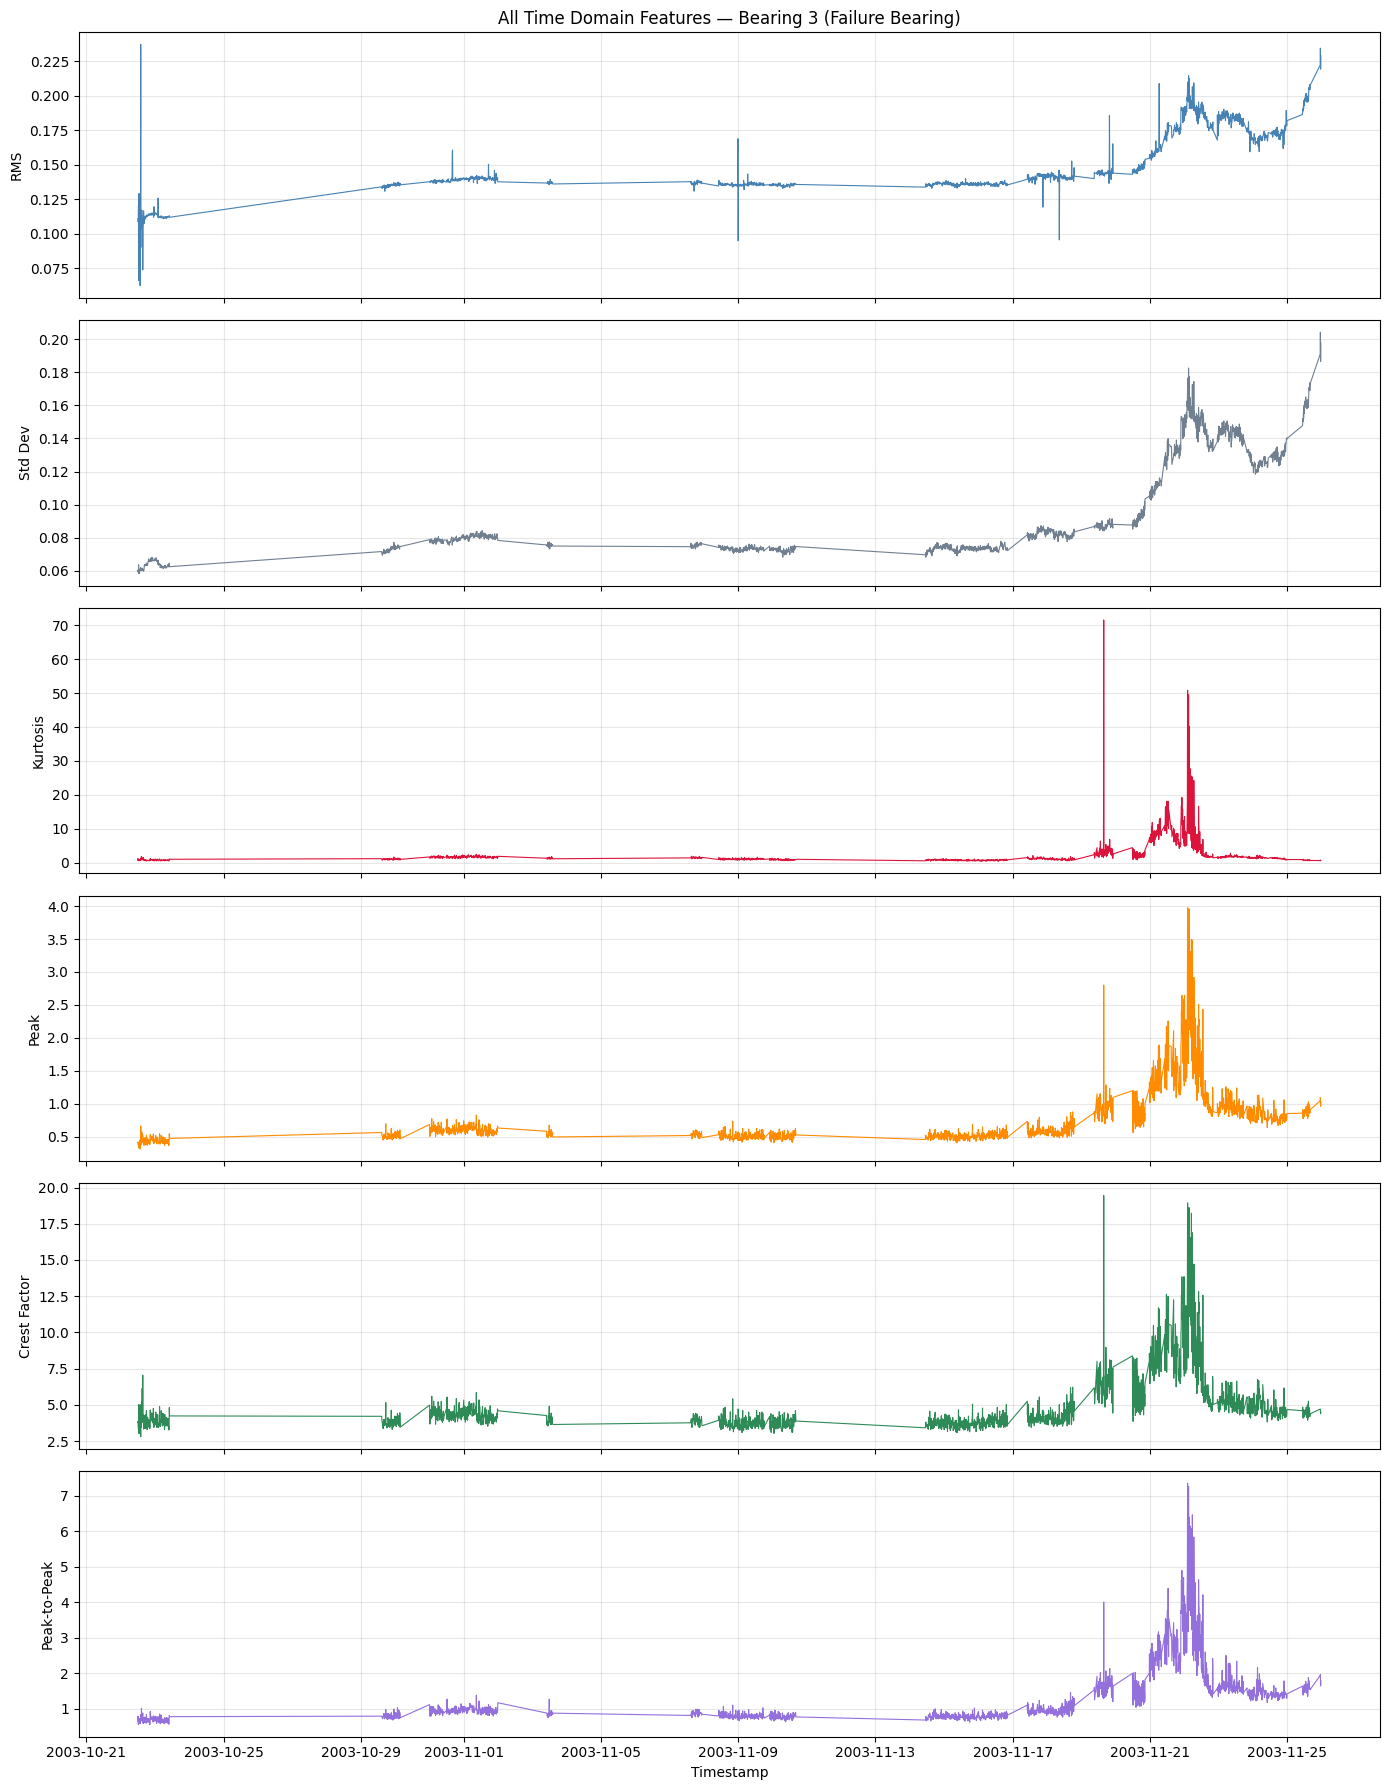

In [3]:
bearing = "bearing_3"
feature_names = ["rms", "std", "kurtosis", "peak", "crest", "peak2peak"]
labels = ["RMS", "Std Dev", "Kurtosis", "Peak", "Crest Factor", "Peak-to-Peak"]
colors = ["steelblue", "slategray", "crimson", "darkorange", "seagreen", "mediumpurple"]

fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)

for i, (feat, label, color) in enumerate(zip(feature_names, labels, colors)):
    axes[i].plot(
        features.index,
        features[f"{bearing}_{feat}"],
        linewidth=0.8,
        color=color
    )
    axes[i].set_ylabel(label)

axes[0].set_title("All Time Domain Features — Bearing 3 (Failure Bearing)")
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.savefig("../outputs/figures/03_all_features_bearing3.png", dpi=150)
plt.show()

## Crest Factor Comparison — All Bearings
Crest Factor is particularly interesting because it can detect early stage faults 
even when RMS is still stable, a high peak relative to overall energy suggests 
isolated impulsive events, characteristic of a developing defect.

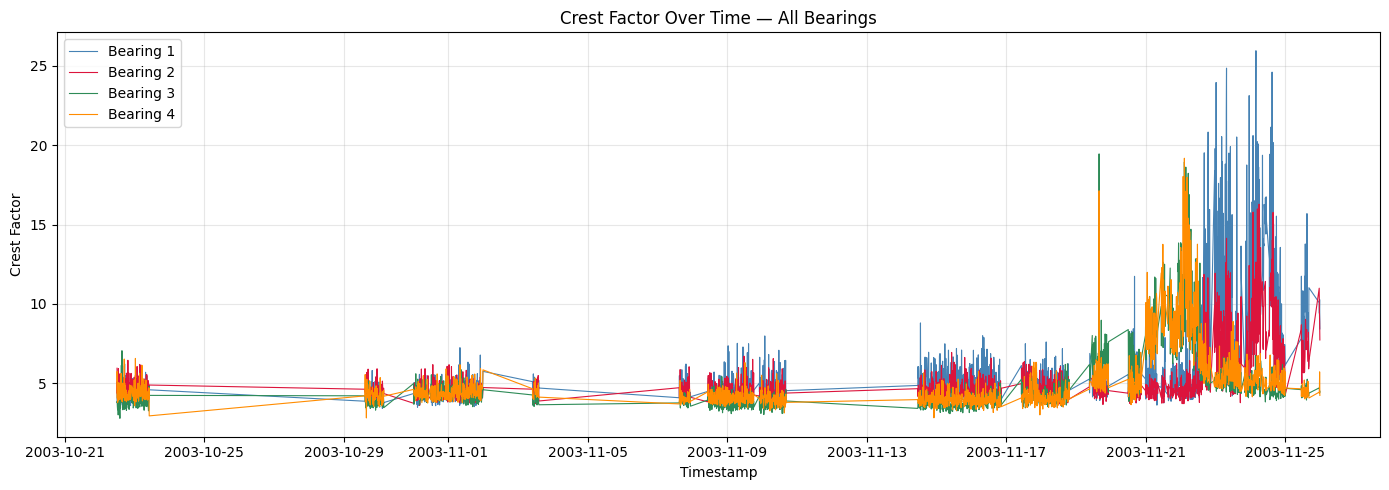

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

for b, color in zip(BEARINGS, COLORS):
    ax.plot(
        features.index,
        features[f"{b}_crest"],
        linewidth=0.8,
        label=b.replace("_", " ").title(),
        color=color
    )

ax.set_title("Crest Factor Over Time — All Bearings")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Crest Factor")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/03_crest_factor_all_bearings.png", dpi=150)
plt.show()

## Feature Correlation Matrix
How correlated are the features with each other for the failure bearing?
Highly correlated features carry redundant information, useful to know 
before building a model.

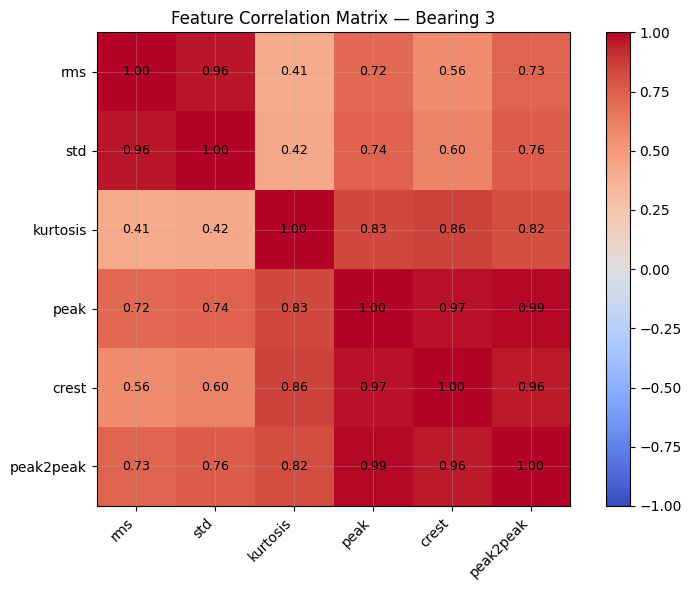

In [5]:
bearing = "bearing_3"
bearing_features = features[[c for c in features.columns if bearing in c]].copy()
bearing_features.columns = [c.replace(f"{bearing}_", "") for c in bearing_features.columns]

corr = bearing_features.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

ax.set_title("Feature Correlation Matrix — Bearing 3")
plt.tight_layout()
plt.savefig("../outputs/figures/03_correlation_matrix.png", dpi=150)
plt.show()

## Key Findings
- **Kurtosis and Crest Factor** react earliest to developing faults, ideal for early warning systems
- **RMS and Peak-to-Peak** confirm late-stage failure with dramatic increases
- **RMS and Std Dev** are highly correlated. In a model, only one is needed
- Bearing 3 shows intermittent instability throughout the test before catastrophic failure,
suggesting progressive damage accumulation rather than sudden onset